<a href="https://colab.research.google.com/github/Syed-Moahmmed-Mujahid/-Task-Management-System/blob/main/Foot_Ball_Players_Salary_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("/content/raw_wages.csv")
df.head(10)

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
0,Cristiano Ronaldo - Portuguese,Al-Nassr (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,POR,Yes,200.0,673,ST (C),38.0,"7,629",31/12/2022,30/6/2025,,-,"€203,478,000 p/a"
1,Karim Benzema - French,Al-Ittihad - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,FRA,Yes,97.0,555,ST (C),35.0,"8,250",1/7/2023,30/6/2025,,-,"€199,452,000 p/a"
2,Neymar - Brazilian,Al-Hilal (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,BRA,Yes,124.0,340,"AM (LC), ST (C)",31.0,"9,000",15/8/2023,30/6/2025,Paris Saint-Germain,€90M,"€149,589,000 p/a"
3,Ezri Konsa - English,Al-Hilal (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,ENG,No,0.0,245,D (C),25.0,"7,414",27/8/2023,30/6/2027,Aston Villa,€55M,"€74,157,000 p/a"
4,Kylian Mbappé - French,Paris Saint-Germain - Ligue 1 Uber Eats,Ligue 1 Uber Eats ...,France (Ligue 1) ...,FRA,Yes,70.0,221,"AM (RL), ST (C)",24.0,"9,415",22/7/2023,30/6/2028,Monaco,€186M,"€48,467,000 p/a"
5,Sadio Mané - Senegalese,Al-Nassr (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,SEN,No,93.0,377,"AM (RLC), ST (C)",31.0,"7,488",1/8/2023,30/6/2027,Bayern München,€28M,"€40,977,000 p/a"
6,Marcelo Brozović - Croatian,Al-Nassr (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,CRO,Yes,87.0,392,"DM, M (C)",30.0,"7,750",3/7/2023,30/6/2026,Inter,€18M,"€35,864,000 p/a"
7,Kalidou Koulibaly - Senegalese,Al-Hilal (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,SEN,Yes,70.0,367,D (C),32.0,"7,500",1/7/2023,30/6/2026,Chelsea,€25M,"€29,918,000 p/a"
8,N'Golo Kanté - French,Al-Ittihad - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,FRA,Yes,53.0,361,"DM, M (C)",32.0,"8,000",19/6/2023,30/6/2026,Chelsea,€0,"€25,624,000 p/a"
9,- -,-,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,SRB,No,81.0,378,,28.0,"7,495",19/8/2023,30/6/2026,Fulham,€50M,"€24,931,000 p/a"


In [ ]:
df.tail()

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
40786,- -,-,Chinese Taipei Football Premier League ...,Chinese Taipei (China PR) (CTP Premier League...,TPE,No,5.0,59,,31.0,"1,508",1/1/2019,31/12/2023,,-,€300 p/a
40787,- -,-,Mauritian Premier Division ...,Mauritius (Premier Division) ...,MRI,No,6.0,1,,21.0,"2,750",4/10/2021,30/6/2024,CTN-FB,-,€300 p/a
40788,- -,-,Somali Premier Division ...,Somalia (Somali Premier Division) ...,SOM,No,2.0,3,,24.0,"3,550",1/7/2023,30/6/2025,Mogadishu City Club,-,€300 p/a
40789,- -,-,Bank of Bhutan Premier League ...,Bhutan (Premier League) ...,BHU,No,3.0,14,,20.0,"1,403",1/1/2021,31/12/2024,Bhutan U19s,€0,€300 p/a
40790,- -,-,Division 1 Norra ...,Sweden (Division 1 Norra) ...,SWE,Yes,0.0,-,,17.0,"3,407",3/7/2023,30/11/2026,,-,€180 p/a


In [ ]:
df.sample(8)

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
20684,- -,-,Liga Portugal Betclic ...,Portugal (Liga Portugal Betclic) ...,GNB,Yes,0.0,-,,19.0,"3,300",23/2/2021,30/6/2024,,-,"€43,000 p/a"
3516,- -,-,Brasileirão Assaí Série A ...,Brazil (Série A) ...,ARG,Yes,6.0,264,,32.0,"6,608",5/7/2021,31/12/2024,,-,"€725,000 p/a"
35430,- -,-,Bremen-Liga ...,Germany (Bremen-Liga) ...,GER,Yes,0.0,-,,19.0,"3,337",1/7/2023,30/6/2024,Werder Bremen,€0,"€10,000 p/a"
30887,- -,-,French National 3 - Group F ...,France (National 3 - Group F) ...,FRA,Yes,0.0,126,,27.0,"4,100",23/6/2023,30/6/2024,,-,"€15,750 p/a"
7398,- -,-,Ligue 2 BKT ...,France (Ligue 2) ...,ALG,Yes,0.0,71,,24.0,"5,781",21/6/2022,30/6/2024,,-,"€263,000 p/a"
3656,- -,-,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,KSA,No,4.0,200,,30.0,"5,000",9/7/2023,30/6/2024,,-,"€684,000 p/a"
8700,- -,-,LigaPro Banco Pichincha ...,Ecuador (LigaPro Serie A) ...,ECU,No,2.0,417,,33.0,"5,860",15/1/2021,31/12/2025,,-,"€200,000 p/a"
358,- -,-,Premier League ...,England (Premier League) ...,FRA,Yes,0.0,198,,25.0,"6,760",31/8/2021,30/6/2025,Celtic,€17.5M,"€5,155,000 p/a"


In [ ]:
print(df.shape)

(40791, 16)


In [ ]:
df.describe()

,Caps,Age
count,40791.000000,40791.000000
mean,5.144370,25.177564
std,13.665878,5.328114
min,0.000000,17.000000
25%,0.000000,21.000000
50%,0.000000,25.000000
75%,3.000000,29.000000
max,200.000000,45.000000


In [ ]:
df.isna()

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40786,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40787,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40788,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
40789,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df1 = df.copy()

In [ ]:
df1.isna().sum()

,0
Name,0
Club,0
Division,0
Based,0
Nat,0
EU National,0
Caps,0
AT Apps,0
Position,0
Age,0


In [ ]:

df1 = df1.convert_dtypes()
print(df1.dtypes)

Name               string[python]
Club               string[python]
Division           string[python]
Based              string[python]
Nat                string[python]
EU National        string[python]
Caps                        Int64
AT Apps            string[python]
Position           string[python]
Age                         Int64
CR                 string[python]
Begins             string[python]
Expires            string[python]
Last Club          string[python]
Last Trans. Fee    string[python]
Salary             string[python]
dtype: object


In [ ]:
# Clean and convert 'Salary' to numeric
df1['Salary'] = df1['Salary'].astype(str).str.replace('€', '', regex=False)
df1['Salary'] = df1['Salary'].astype(str).str.replace(' p/a', '', regex=False)
df1['Salary'] = df1['Salary'].astype(str).str.replace(',', '', regex=False)
df1['Salary'] = pd.to_numeric(df1['Salary'], errors='coerce')

# Display data types to confirm the change
print(df1.dtypes)
# Display the head to see the cleaned salary values
display(df1.head())

Name               string[python]
Club               string[python]
Division           string[python]
Based              string[python]
Nat                string[python]
EU National        string[python]
Caps                        Int64
AT Apps            string[python]
Position           string[python]
Age                         Int64
CR                 string[python]
Begins             string[python]
Expires            string[python]
Last Club          string[python]
Last Trans. Fee    string[python]
Salary                      int64
dtype: object


,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
0,Cristiano Ronaldo - Portuguese,Al-Nassr (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,POR,Yes,200,673,ST (C),38,"7,629",31/12/2022,30/6/2025,,-,203478000
1,Karim Benzema - French,Al-Ittihad - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,FRA,Yes,97,555,ST (C),35,"8,250",1/7/2023,30/6/2025,,-,199452000
2,Neymar - Brazilian,Al-Hilal (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,BRA,Yes,124,340,"AM (LC), ST (C)",31,"9,000",15/8/2023,30/6/2025,Paris Saint-Germain,€90M,149589000
3,Ezri Konsa - English,Al-Hilal (KSA) - Roshn Saudi League,Roshn Saudi League ...,Saudi Arabia (Saudi Pro League) ...,ENG,No,0,245,D (C),25,"7,414",27/8/2023,30/6/2027,Aston Villa,€55M,74157000
4,Kylian Mbappé - French,Paris Saint-Germain - Ligue 1 Uber Eats,Ligue 1 Uber Eats ...,France (Ligue 1) ...,FRA,Yes,70,221,"AM (RL), ST (C)",24,"9,415",22/7/2023,30/6/2028,Monaco,€186M,48467000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40791 entries, 0 to 40790
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Name             40791 non-null  string
 1   Club             40791 non-null  string
 2   Division         40791 non-null  string
 3   Based            40791 non-null  string
 4   Nat              40791 non-null  string
 5   EU National      40791 non-null  string
 6   Caps             40791 non-null  Int64 
 7   AT Apps          40791 non-null  string
 8   Position         40791 non-null  string
 9   Age              40791 non-null  Int64 
 10  CR               40791 non-null  string
 11  Begins           40791 non-null  string
 12  Expires          40791 non-null  string
 13  Last Club        40791 non-null  string
 14  Last Trans. Fee  40791 non-null  string
 15  Salary           40791 non-null  int64 
dtypes: Int64(2), int64(1), string(13)
memory usage: 5.1 MB


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

cols = ["Name","Club","Division","Based" ,"AT Apps","Nat","EU National","Position","CR","Begins","Expires","Last Club","Last Trans. Fee","Salary"]

for col in cols:
    df1[col] = le.fit_transform(df1[col])

In [ ]:
df1 = df1.convert_dtypes()
print(df1.dtypes)

Name               Int64
Club               Int64
Division           Int64
Based              Int64
Nat                Int64
EU National        Int64
Caps               Int64
AT Apps            Int64
Position           Int64
Age                Int64
CR                 Int64
Begins             Int64
Expires            Int64
Last Club          Int64
Last Trans. Fee    Int64
Salary             Int64
dtype: object


In [ ]:
df1.head(25)

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
0,1,3,589,629,155,1,200,584,6,38,4859,1085,130,0,0,1964
1,4,2,589,629,66,1,97,505,6,35,5000,45,130,0,0,1963
2,8,1,589,629,28,1,124,269,1,31,5037,323,130,3484,339,1962
3,2,1,589,629,58,0,0,163,4,25,4782,892,132,558,248,1961
4,5,4,430,243,66,1,70,137,2,24,5045,668,133,3097,83,1960
5,9,3,589,629,165,0,93,309,3,31,4805,51,132,761,146,1959
6,6,3,589,629,46,1,87,326,5,30,4901,1020,131,2398,84,1958
7,3,1,589,629,165,1,70,298,4,32,4810,45,131,1188,136,1957
8,7,2,589,629,66,1,53,292,5,32,4969,484,131,1188,1,1956
9,0,0,589,629,176,0,81,310,0,28,4808,492,131,1972,238,1955


In [ ]:
df1.isna().sum()

,0
Name,0
Club,0
Division,0
Based,0
Nat,0
EU National,0
Caps,0
AT Apps,0
Position,0
Age,0


In [ ]:
df1.corr()

,Name,Club,Division,Based,Nat,EU National,Caps,AT Apps,Position,Age,CR,Begins,Expires,Last Club,Last Trans. Fee,Salary
Name,1.000000,0.830237,0.007614,0.010217,-0.001607,0.003755,0.078095,0.006222,0.731163,0.013323,0.032831,-0.003390,-0.002105,0.000238,0.024457,0.058583
Club,0.830237,1.000000,0.006933,0.008299,0.000791,0.005066,0.089305,0.008212,0.850392,0.014095,0.033435,0.000814,-0.002038,-0.001710,0.015412,0.059837
Division,0.007614,0.006933,1.000000,0.291165,0.088196,-0.028673,-0.043671,0.014019,0.008471,-0.054977,-0.026125,0.026053,-0.098547,0.045801,0.029113,0.017360
Based,0.010217,0.008299,0.291165,1.000000,0.316919,0.070338,0.026730,0.051264,0.012006,0.074861,0.025994,0.025495,-0.001892,0.054036,-0.038964,-0.022244
Nat,-0.001607,0.000791,0.088196,0.316919,1.000000,-0.143510,0.118012,0.001162,0.001212,0.044082,-0.025851,0.013311,0.052622,-0.010515,0.001778,-0.012920
EU National,0.003755,0.005066,-0.028673,0.070338,-0.143510,1.000000,-0.192356,-0.038432,0.005327,-0.153518,0.020945,-0.031117,-0.227069,0.018906,-0.006664,-0.008992
Caps,0.078095,0.089305,-0.043671,0.026730,0.118012,-0.192356,1.000000,0.060194,0.087217,0.333104,0.225815,0.051177,0.094833,0.047509,0.095958,0.313528
AT Apps,0.006222,0.008212,0.014019,0.051264,0.001162,-0.038432,0.060194,1.000000,0.010634,0.162619,0.168556,0.015808,0.036988,0.082818,0.024855,0.065589
Position,0.731163,0.850392,0.008471,0.012006,0.001212,0.005327,0.087217,0.010634,1.000000,0.017324,0.033843,0.000209,-0.002410,-0.005317,0.014205,0.061065
Age,0.013323,0.014095,-0.054977,0.074861,0.044082,-0.153518,0.333104,0.162619,0.017324,1.000000,0.318066,0.039234,0.121962,0.143381,0.016540,0.191678


In [ ]:
# Define features (X) and target (y)
x = df1[["Name","Club","Division","Based" ,"AT Apps","Nat","EU National","Position","CR","Begins","Expires","Last Club","Last Trans. Fee"]]
y = df1['Salary']

In [ ]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [ ]:
#random forest
from sklearn.ensemble import RandomForestRegressor
rf= RandomForestRegressor()
rf.fit(x_train, y_train)

RandomForestRegressor()

In [ ]:
y_pred = rf.predict(x_test)

In [ ]:
score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.868687499010251


In [ ]:
#same input form this dataset
input_data=(1, 3, 589, 629, 584, 155, 1, 6, 4859, 1085, 130, 0, 0)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=rf.predict(input_data_reshaped)
print(prediction)

[1632.48]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# This new input and output is not present in the dataset
input_data=(2, 4, 559, 689, 684, 255, 6, 7, 5859, 4085, 730, 0, 0)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
prediction=rf.predict(input_data_reshaped)
print(prediction)

[171.55]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# Choose a row from the preprocessed DataFrame df1 (e.g., the first row)
row_index = 0  # <--- Change this value to select a different row
selected_row = df1.iloc[row_index]

# Extract the feature values for prediction, ensuring column order matches 'x'
input_data = selected_row[x.columns].values

# Convert the numpy array to a DataFrame with feature names
# The column names should match the features used during training ('x')
input_df = pd.DataFrame(input_data.reshape(1, -1), columns=x.columns)

# Get the model's prediction
prediction = rf.predict(input_df)

# Get the actual salary from the dataset
actual_salary = selected_row['Salary']

print(f"Input taken from row index: {row_index}")
print(f"Predicted Salary: {prediction[0]:.2f}")
print(f"Actual Salary: {actual_salary}")

Input taken from row index: 0
Predicted Salary: 1632.48
Actual Salary: 1964


# maps and graphs

#Pair Plot

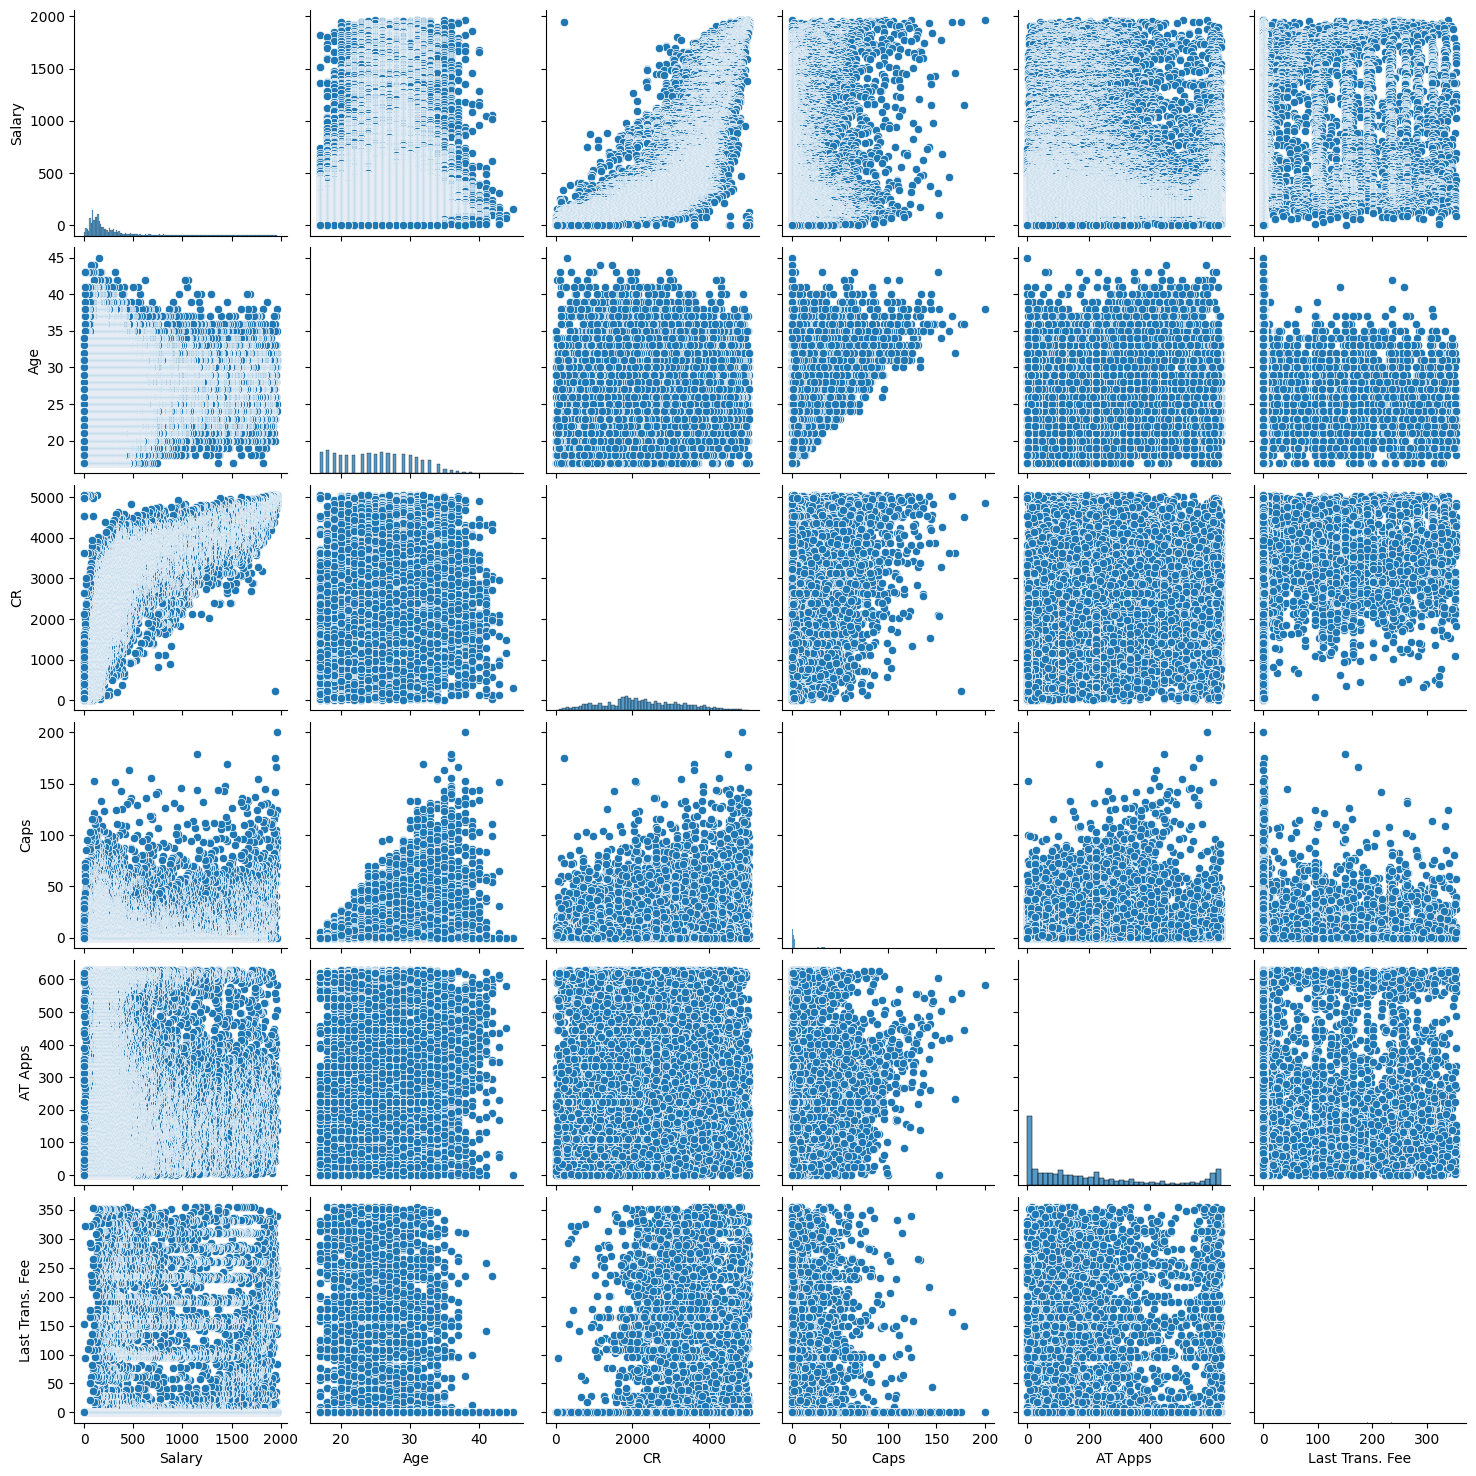

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# select important numeric columns
cols = ["Salary", "Age", "CR", "Caps", "AT Apps", "Last Trans. Fee"]

sns.pairplot(df1[cols])
plt.show()

#Bar Graph

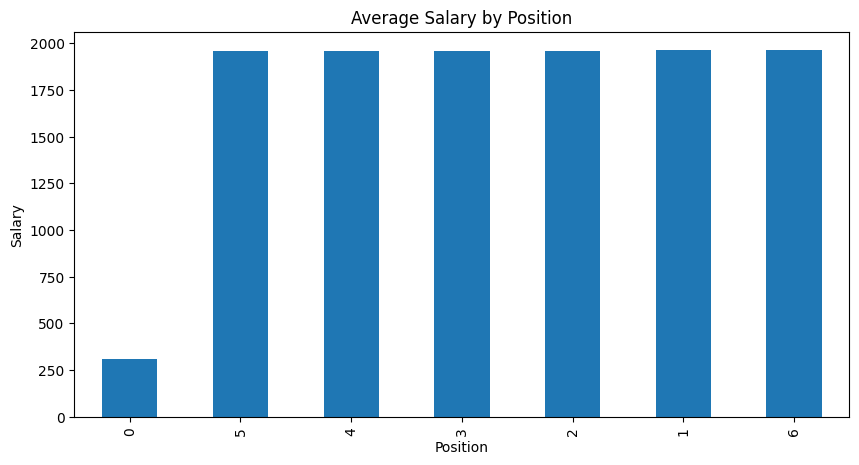

In [ ]:
plt.figure(figsize=(10,5))

df1.groupby("Position")["Salary"].mean().sort_values().plot(kind='bar')

plt.title("Average Salary by Position")
plt.xlabel("Position")
plt.ylabel("Salary")
plt.show()

#Box Plot

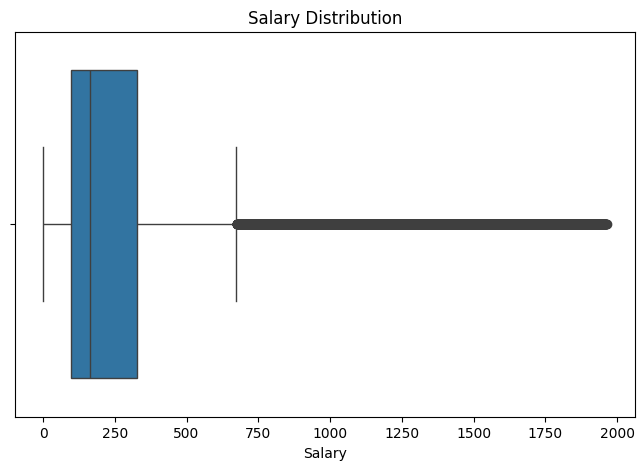

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df1["Salary"])

plt.title("Salary Distribution")
plt.show()

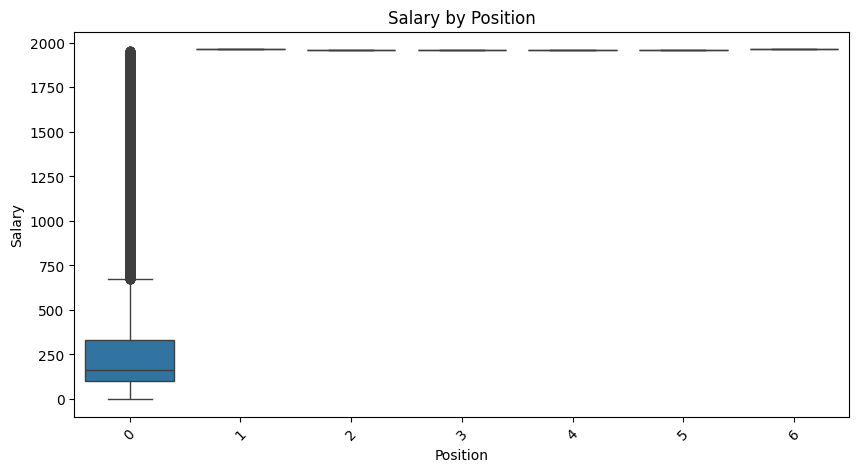

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x="Position", y="Salary", data=df1)

plt.xticks(rotation=45)
plt.title("Salary by Position")
plt.show()

#Scatter Plot
1.CR vs Salary

2.Age vs Salary

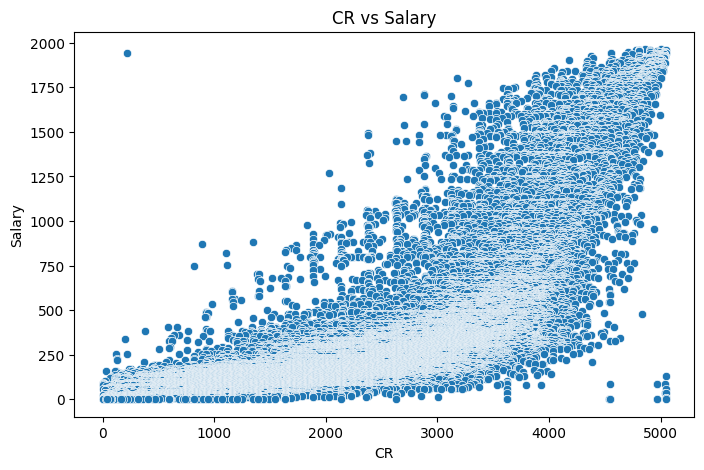

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="CR", y="Salary", data=df1)

plt.title("CR vs Salary")
plt.show()

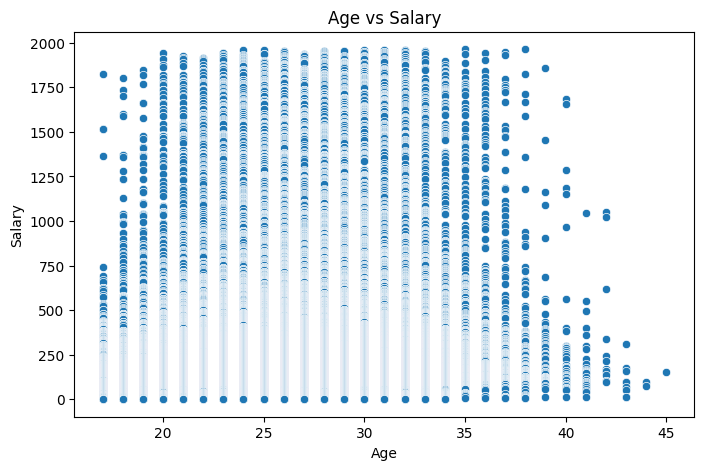

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="Age", y="Salary", data=df1)

plt.title("Age vs Salary")
plt.show()

#Heat map 2

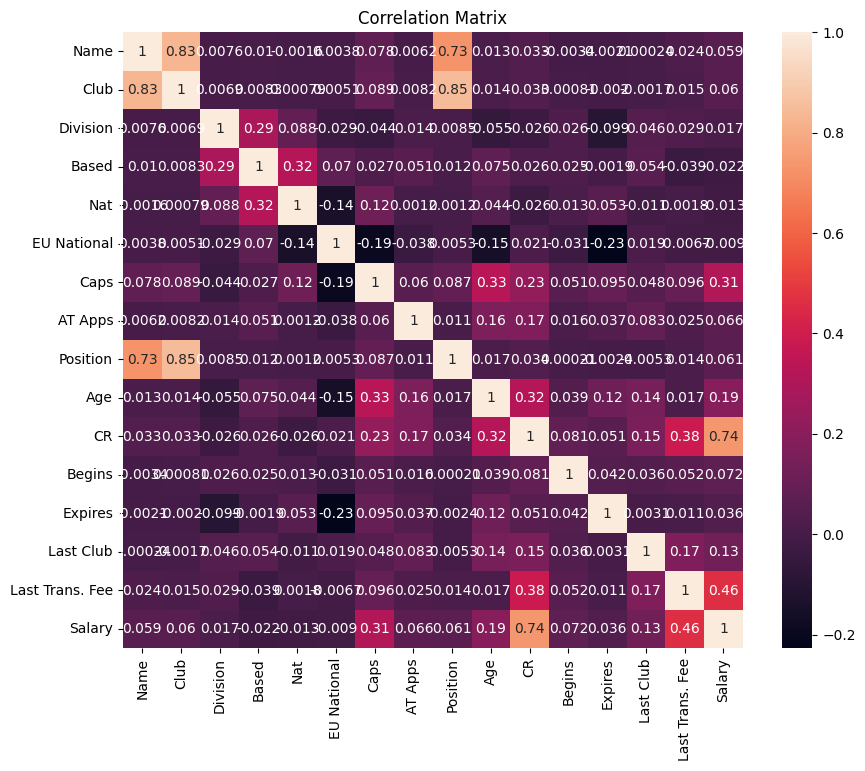

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df1.corr(numeric_only=True), annot=True)

plt.title("Correlation Matrix")
plt.show()

#Gradio interface

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

# Define the prediction function for Gradio
def predict_salary(*args):
    # Ensure the input matches the features x used for training
    feature_names = x.columns.tolist()
    input_data = pd.DataFrame([args], columns=feature_names)

    # Make prediction using the trained model
    prediction = rf.predict(input_data)[0]

    return f"Predicted Salary: {prediction:.2f}"

# Create Gradio input components based on the features in 'x'
inputs = []
for col_name in x.columns:
    inputs.append(gr.Number(label=col_name))

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_salary,
    inputs=inputs,
    outputs=gr.Textbox(label="Predicted Salary"),
    title="Salary Prediction using RandomForestRegressor",
    description="Enter the encoded feature values to predict player salary."
)

# Launch the interface
iface.launch()